# Module 12 — Bayesian Black-Box Optimisation
## Week 1 Submission

**Strategy:** Gaussian Process (GP) + UCB with adaptive beta values

| Function | Dimensions | Beta | Description |
|---|---|---|---|
| F1 | 2D | 2.5 | Radiation Detection |
| F2 | 2D | 2.5 | Noisy ML Model |
| F3 | 3D | 1.5 | Drug Discovery |
| F4 | 4D | 2.5 | Warehouse Placement |
| F5 | 4D | 1.0 | Chemical Yield |
| F6 | 5D | 1.5 | Cake Recipe |
| F7 | 6D | 1.5 | ML Hyperparameters |
| F8 | 8D | 1.0 | 8D Optimisation |


## Cell 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## Cell 2 — Settings and Data Load

In [2]:
# Change this to your data path
base_path = '/Users/luckydhanvi/Downloads/initial_data/'

betas = {1:2.5, 2:2.5, 3:1.5, 4:2.5, 5:1.0, 6:1.5, 7:1.5, 8:1.0}

descriptions = {
    1:'Radiation Detection',  2:'Noisy ML Model',
    3:'Drug Discovery',       4:'Warehouse Placement',
    5:'Chemical Yield',       6:'Cake Recipe',
    7:'ML Hyperparameters',   8:'8D Optimisation'
}

# Load all data
data = {}
for i in range(1, 9):
    X = np.load(f'{base_path}function_{i}/initial_inputs.npy')
    Y = np.load(f'{base_path}function_{i}/initial_outputs.npy')
    data[i] = {'X': X, 'Y': Y}
    print(f'F{i} ({descriptions[i]}) — Shape: {X.shape} | Best Y: {Y.max():.4e}')

F1 (Radiation Detection) — Shape: (10, 2) | Best Y: 7.7109e-16
F2 (Noisy ML Model) — Shape: (10, 2) | Best Y: 6.1121e-01
F3 (Drug Discovery) — Shape: (15, 3) | Best Y: -3.4835e-02
F4 (Warehouse Placement) — Shape: (30, 4) | Best Y: -4.0255e+00
F5 (Chemical Yield) — Shape: (20, 4) | Best Y: 1.0889e+03
F6 (Cake Recipe) — Shape: (20, 5) | Best Y: -7.1426e-01
F7 (ML Hyperparameters) — Shape: (30, 6) | Best Y: 1.3650e+00
F8 (8D Optimisation) — Shape: (40, 8) | Best Y: 9.5985e+00


## Cell 3 — Helper Functions

In [3]:
def inspect_data(func_num):
    """Print sorted data table."""
    X = data[func_num]['X']
    Y = data[func_num]['Y']

    pairs = sorted(zip(Y, X), reverse=True)
    Y_sorted = [p[0] for p in pairs]
    X_sorted = [p[1] for p in pairs]

    print(f'\nFunction {func_num} — {descriptions[func_num]} ({X.shape[1]}D)')
    print('=' * 65)
    print('  All observations (sorted descending by Y)')
    print('=' * 65)
    for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
        marker = '  <-- best' if i == 0 else ''
        x_str = ', '.join([f'{v:.6f}' for v in x_val])
        print(f'  [{i+1:2d}]  X=[{x_str}]  Y={y_val:+.4e}{marker}')
    print('=' * 65)
    print(f'  Best Y* = {Y_sorted[0]:.6e}')
    return np.array(X_sorted[0]), Y_sorted[0]


def fit_gp(func_num):
    """Fit GP with log transform."""
    X = data[func_num]['X']
    Y = data[func_num]['Y']
    Y_fit = np.log(np.abs(Y) + 1e-300)
    kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, Y_fit)
    print(f'  Kernel: {gp.kernel_}')
    return gp


def ucb_search(func_num, gp, beta):
    """
    Smart grid size based on dimensions.
    2D → 50x50 grid
    3D → 20x20x20 grid
    4D+ → 5000 random points (memory safe!)
    """
    X = data[func_num]['X']
    dim = X.shape[1]

    if dim == 2:
        # 50x50 grid for 2D
        x1 = np.linspace(0, 1, 50)
        x2 = np.linspace(0, 1, 50)
        XX1, XX2 = np.meshgrid(x1, x2)
        X_grid = np.column_stack([XX1.ravel(), XX2.ravel()])
        print(f'  Grid: 50x50 = {len(X_grid)} points')
    elif dim == 3:
        # 20x20x20 grid for 3D
        axes = [np.linspace(0, 1, 20) for _ in range(3)]
        grids = np.meshgrid(*axes)
        X_grid = np.column_stack([g.ravel() for g in grids])
        print(f'  Grid: 20^3 = {len(X_grid)} points')
    else:
        # Random search for 4D+ (memory safe!)
        np.random.seed(42)
        X_grid = np.random.uniform(0, 1, (5000, dim))
        print(f'  Random search: 5000 points ({dim}D)')

    # GP predict
    post_mean, post_std = gp.predict(X_grid, return_std=True)
    acquisition = post_mean + beta * post_std
    best_idx = np.argmax(acquisition)
    next_x = X_grid[best_idx]
    portal_string = '-'.join([f'{v:.6f}' for v in next_x])

    print(f'  Max UCB : {acquisition[best_idx]:.4f}')
    print(f'  >>> Portal: {portal_string} <<<')

    return next_x, portal_string, post_mean, post_std, acquisition, X_grid


print('Helper functions ready!')

Helper functions ready!


## Cell 4 — Analyse All 8 Functions

In [4]:
results = {}

for i in range(1, 9):
    print(f'\n{"="*65}')
    print(f'  FUNCTION {i} — {descriptions[i]}')
    print(f'{"="*65}')

    best_X, best_Y = inspect_data(i)

    print('\n  GP Fitting:')
    gp = fit_gp(i)

    print(f'\n  UCB (beta={betas[i]}):')
    next_x, portal, mu, sigma, acq, X_grid = ucb_search(i, gp, betas[i])

    results[i] = {
        'best_X': best_X, 'best_Y': best_Y,
        'gp': gp, 'next_x': next_x,
        'portal': portal,
        'mu': mu, 'sigma': sigma,
        'acq': acq, 'X_grid': X_grid
    }


  FUNCTION 1 — Radiation Detection

Function 1 — Radiation Detection (2D)
  All observations (sorted descending by Y)
  [ 1]  X=[0.731024, 0.733000]  Y=+7.7109e-16  <-- best
  [ 2]  X=[0.683418, 0.861057]  Y=+2.5350e-40
  [ 3]  X=[0.574329, 0.879898]  Y=+1.0331e-46
  [ 4]  X=[0.883890, 0.582254]  Y=+6.2299e-48
  [ 5]  X=[0.319404, 0.762959]  Y=+1.3227e-79
  [ 6]  X=[0.082507, 0.403488]  Y=+3.6068e-81
  [ 7]  X=[0.840353, 0.264732]  Y=+3.3418e-124
  [ 8]  X=[0.312691, 0.078723]  Y=-2.0891e-91
  [ 9]  X=[0.410437, 0.147554]  Y=-2.1592e-54
  [10]  X=[0.650114, 0.681526]  Y=-3.6061e-03
  Best Y* = 7.710875e-16

  GP Fitting:
  Kernel: RBF(length_scale=0.1)

  UCB (beta=2.5):
  Grid: 50x50 = 2500 points
  Max UCB : 9.3719
  >>> Portal: 0.591837-0.591837 <<<

  FUNCTION 2 — Noisy ML Model

Function 2 — Noisy ML Model (2D)
  All observations (sorted descending by Y)
  [ 1]  X=[0.702637, 0.926564]  Y=+6.1121e-01  <-- best
  [ 2]  X=[0.665800, 0.123969]  Y=+5.3900e-01
  [ 3]  X=[0.877791, 0.77

## Cell 5 — Heatmaps for F1 and F2 (2D only)

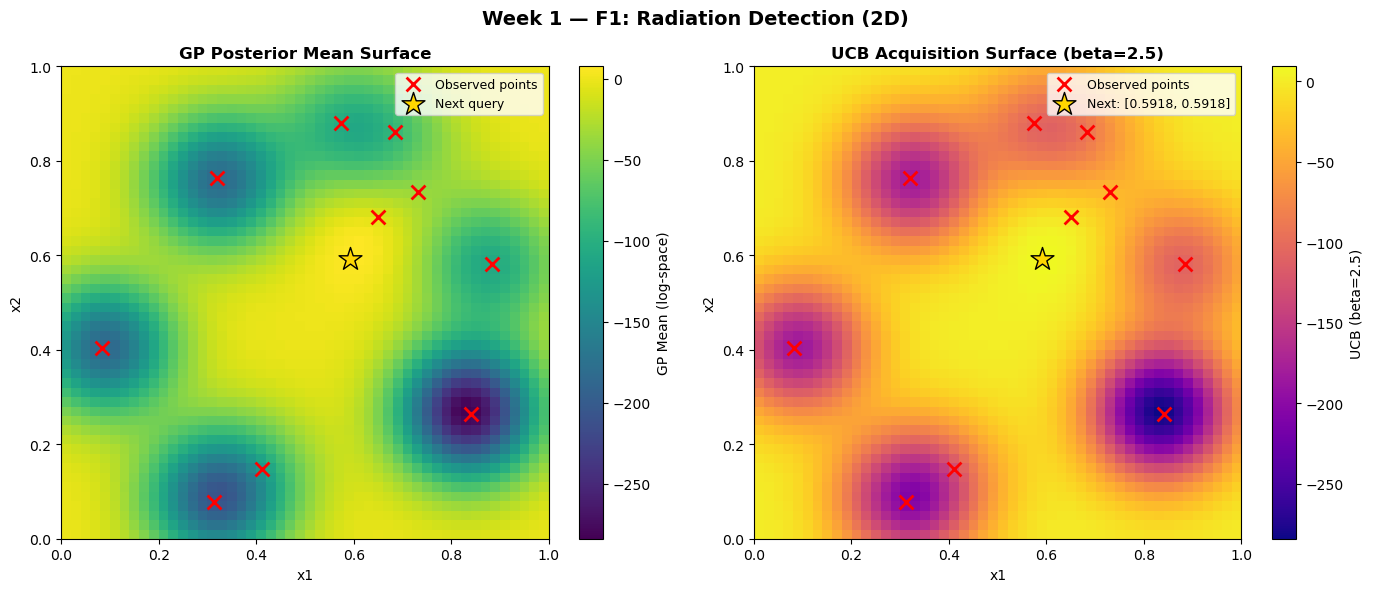

F1 heatmap saved!


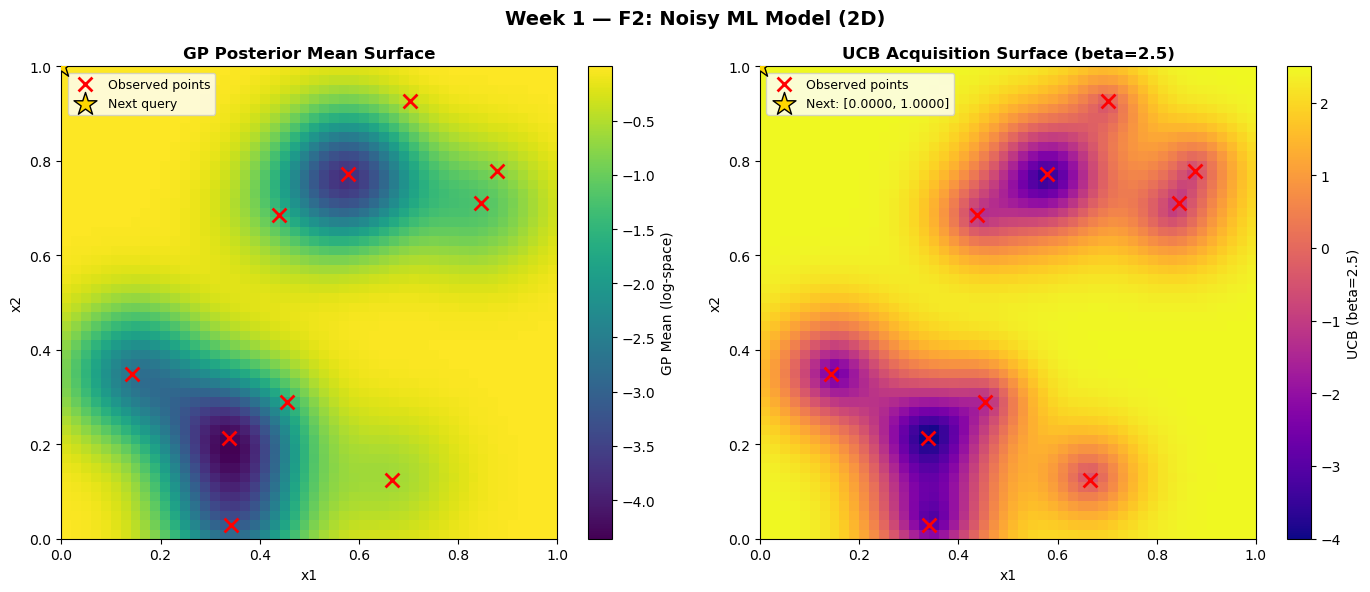

F2 heatmap saved!


In [5]:
for func_num in [1, 2]:
    X = data[func_num]['X']
    next_x = results[func_num]['next_x']
    mu = results[func_num]['mu']
    acq = results[func_num]['acq']
    beta = betas[func_num]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    im1 = ax1.imshow(mu.reshape(50,50), origin='lower',
                     extent=[0,1,0,1], aspect='auto', cmap='viridis')
    plt.colorbar(im1, ax=ax1, label='GP Mean (log-space)')
    ax1.scatter(X[:,0], X[:,1], c='r', marker='x', s=100,
                linewidths=2, label='Observed points', zorder=5)
    ax1.scatter(next_x[0], next_x[1], c='gold', marker='*', s=300,
                edgecolors='black', zorder=6, label='Next query')
    ax1.set_title('GP Posterior Mean Surface', fontsize=12, fontweight='bold')
    ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
    ax1.legend(fontsize=9)

    im2 = ax2.imshow(acq.reshape(50,50), origin='lower',
                     extent=[0,1,0,1], aspect='auto', cmap='plasma')
    plt.colorbar(im2, ax=ax2, label=f'UCB (beta={beta})')
    ax2.scatter(X[:,0], X[:,1], c='r', marker='x', s=100,
                linewidths=2, label='Observed points', zorder=5)
    ax2.scatter(next_x[0], next_x[1], c='gold', marker='*', s=300,
                edgecolors='black', zorder=6,
                label=f'Next: [{next_x[0]:.4f}, {next_x[1]:.4f}]')
    ax2.set_title(f'UCB Acquisition Surface (beta={beta})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
    ax2.legend(fontsize=9)

    plt.suptitle(f'Week 1 — F{func_num}: {descriptions[func_num]} (2D)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'F{func_num}_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'F{func_num} heatmap saved!')

## Cell 6 — Overview Bar Charts (All 8 Functions)

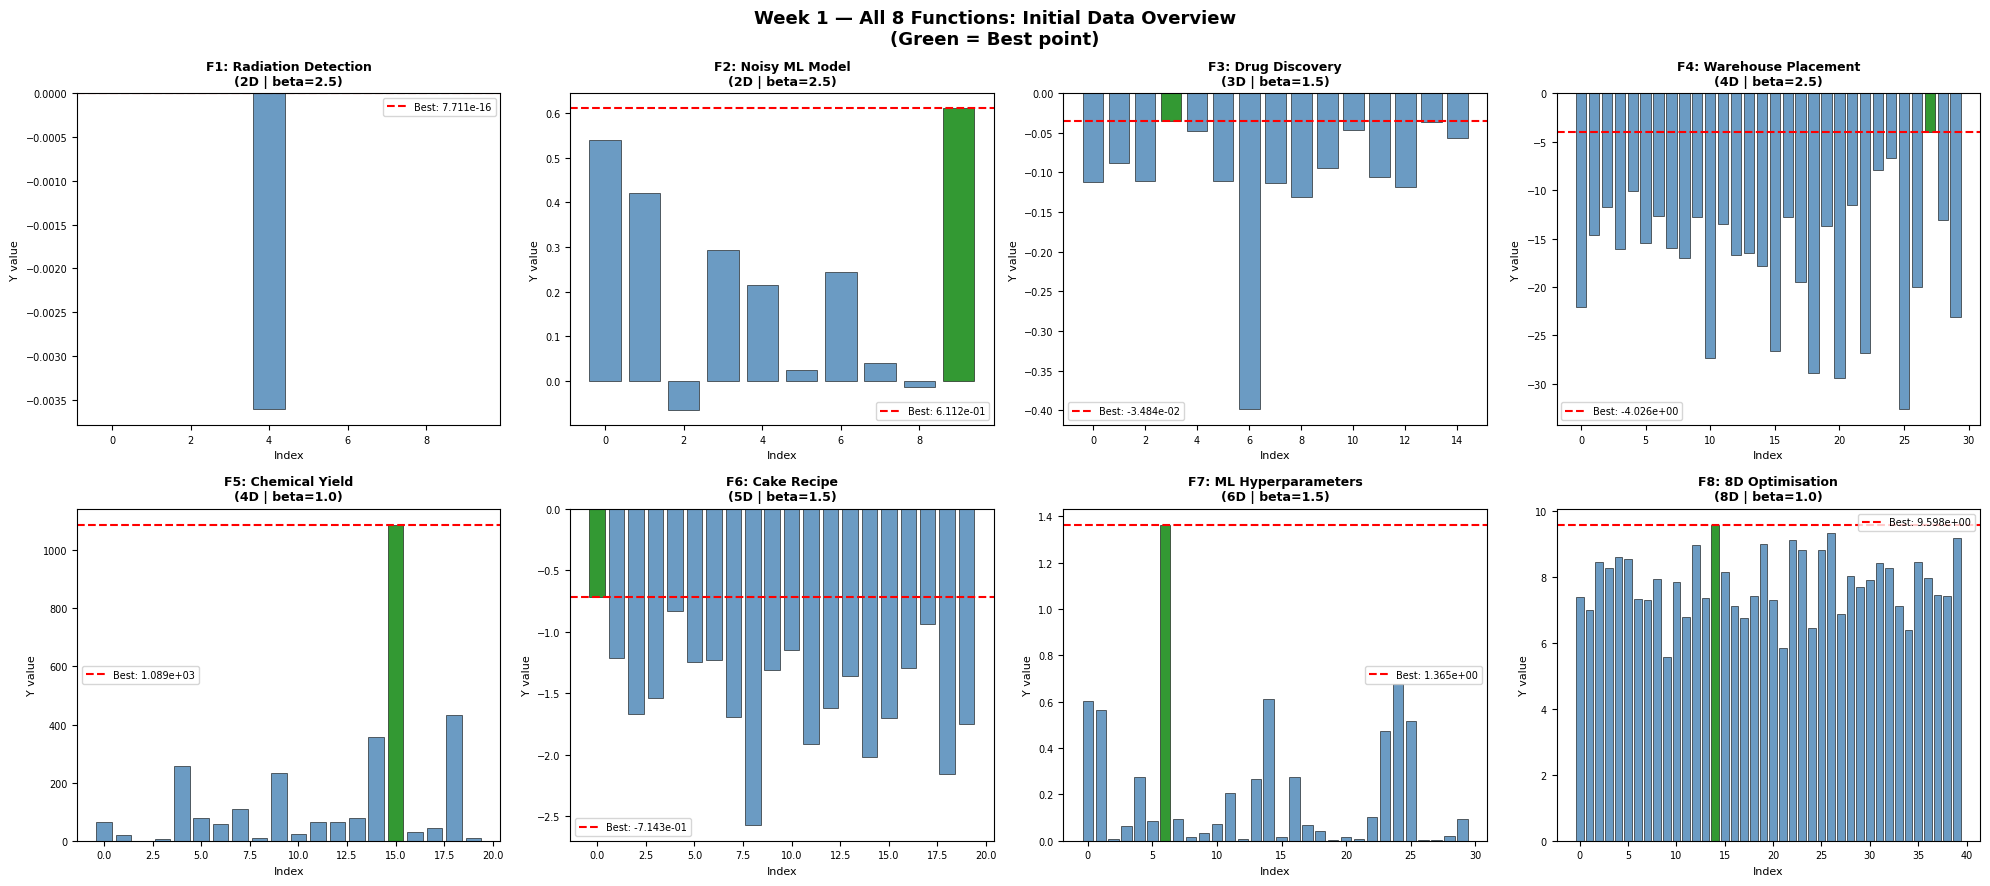

Overview plot saved!


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i in range(1, 9):
    X = data[i]['X']
    Y = data[i]['Y']
    ax = axes[i-1]
    colors = ['green' if val == Y.max() else 'steelblue' for val in Y]
    ax.bar(range(len(Y)), Y, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
    ax.axhline(y=Y.max(), color='red', linestyle='--', lw=1.5,
               label=f'Best: {Y.max():.3e}')
    ax.set_title(f'F{i}: {descriptions[i]}\n({X.shape[1]}D | beta={betas[i]})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Index', fontsize=8)
    ax.set_ylabel('Y value', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Week 1 — All 8 Functions: Initial Data Overview\n(Green = Best point)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('All_Functions_Overview.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Overview plot saved!')

## Cell 7 — Final Summary Table

In [7]:
print('FINAL SUBMISSION SUMMARY — Week 1')
print('=' * 75)
print(f'{"Fn":<4} {"Description":<22} {"Dim":<5} {"Beta":<6} {"Best Y":<16} {"Submit This"}')
print('-' * 75)

for i in range(1, 9):
    X = data[i]['X']
    Y = data[i]['Y']
    portal = results[i]['portal']
    print(f'F{i:<3} {descriptions[i]:<22} {X.shape[1]:<5} {betas[i]:<6} {Y.max():<16.4e} {portal}')

print('=' * 75)
print('\nStrategy  : GP (RBF kernel, fixed) + UCB adaptive beta')
print('Transform : log(|Y| + 1e-300)')
print('Search    : Grid (2D/3D) + Random 5000 pts (4D+)')

FINAL SUBMISSION SUMMARY — Week 1
Fn   Description            Dim   Beta   Best Y           Submit This
---------------------------------------------------------------------------
F1   Radiation Detection    2     2.5    7.7109e-16       0.591837-0.591837
F2   Noisy ML Model         2     2.5    6.1121e-01       0.000000-1.000000
F3   Drug Discovery         3     1.5    -3.4835e-02      0.421053-1.000000-1.000000
F4   Warehouse Placement    4     2.5    -4.0255e+00      0.909548-0.568955-0.762175-0.811807
F5   Chemical Yield         4     1.0    1.0889e+03       0.204881-0.877830-0.879582-0.870578
F6   Cake Recipe            5     1.5    -7.1426e-01      0.851439-0.906254-0.506372-0.594105-0.708147
F7   ML Hyperparameters     6     1.5    1.3650e+00       0.158655-0.531857-0.281519-0.096244-0.466958-0.590109
F8   8D Optimisation        8     1.0    9.5985e+00       0.076274-0.101214-0.383035-0.338493-0.113685-0.882235-0.615428-0.796463

Strategy  : GP (RBF kernel, fixed) + UCB adaptive

## Cell 8 — Next Week Update

In [8]:
def update_and_suggest(func_num, submitted_x, new_y):
    """
    Update dataset and suggest next query.
    
    Usage:
    update_and_suggest(1, [0.155995, 0.058084], 0.5)
    """
    X = data[func_num]['X']
    Y = data[func_num]['Y']

    X_new = np.vstack([X, submitted_x])
    Y_new = np.append(Y, new_y)
    data[func_num]['X'] = X_new
    data[func_num]['Y'] = Y_new

    print(f'Function {func_num} updated!')
    print(f'  Points : {len(Y_new)}')
    print(f'  New Y  : {new_y:.4e}')
    print(f'  Best Y : {Y_new.max():.4e}')

    gp = fit_gp(func_num)
    _, portal, _, _, _, _ = ucb_search(func_num, gp, betas[func_num])
    return portal

# EXAMPLE — Next week:
# update_and_suggest(1, [0.155995, 0.058084], 0.5)

print('Ready for next week!')

Ready for next week!


## Reflection

**Strategy:** GP with RBF fixed kernel + UCB acquisition with adaptive beta values.

**Log transform:** Applied to handle extreme Y scale differences (F1 outputs near 1e-16).

**Search:** 50x50 grid for 2D, 20^3 for 3D, random 5000 points for 4D+ (memory efficient).

**Most challenging:** Function 1 — all outputs near zero, GP had almost no signal.

**Next steps:** Update beta per function based on new results each week.